# GPT-2 Result Analysis

This notebook summarizes the training and inference quality of the character-level GPT model stored in `gpt2_logs/gpt-mini/version_0`.

It covers:
- run metadata and hyperparameters
- TensorBoard scalar history (loss and accuracy)
- qualitative generation from the trained checkpoint (greedy and sampled decoding)

In [1]:
from pathlib import Path
import argparse
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import torch

from dataset import CharTokenizer
from gpt import GPT

In [2]:
ROOT = Path.cwd()
RUN_DIR = ROOT / 'gpt2_logs' / 'gpt-mini' / 'version_0'
EVENT_FILE = next(RUN_DIR.glob('events.out.tfevents.*'))
CKPT_DIR = RUN_DIR / 'checkpoints'
CKPT_PATH = sorted(CKPT_DIR.glob('*.ckpt'))[-1]
HPARAMS_PATH = RUN_DIR / 'hparams.yaml'

print(f'Run dir: {RUN_DIR}')
print(f'Event file: {EVENT_FILE.name}')
print(f'Checkpoint: {CKPT_PATH.name}')

Run dir: /home/minjih/Deep_Learning/assignment2/gpt2_logs/gpt-mini/version_0
Event file: events.out.tfevents.1775543368.ng31103.4160530.0
Checkpoint: epoch=4-step=21095.ckpt


In [3]:
with open(HPARAMS_PATH, 'r') as f:
    # Lightning hparams can include !!python/tuple (e.g., betas).
    # Use FullLoader first, then fallback for this trusted local artifact.
    try:
        hparams = yaml.load(f, Loader=yaml.FullLoader)
    except yaml.constructor.ConstructorError:
        f.seek(0)
        hparams = yaml.unsafe_load(f)

hparams_df = pd.DataFrame(sorted(hparams.items()), columns=['hyperparameter', 'value'])
hparams_df

,hyperparameter,value
0,abs_emb,False
1,betas,"(0.9, 0.95)"
2,block_size,128
3,clip_grad_norm,1.0
4,compile,False
5,device,cuda
6,generate_batch_size,5
7,generate_every_n_steps,1000
8,learning_rate,0.0005
9,log_dir,/lustre06/project/6016730/minjihk/uvadlc_pract...


In [4]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(str(EVENT_FILE))
ea.Reload()
scalar_tags = ea.Tags().get('scalars', [])
print('Scalar tags:')
for t in scalar_tags:
    print(' -', t)

rows = []
for tag in scalar_tags:
    for e in ea.Scalars(tag):
        rows.append({'tag': tag, 'step': e.step, 'value': e.value})

scalars_df = pd.DataFrame(rows)
print('\nTotal scalar points:', len(scalars_df))
scalars_df.head()

Scalar tags:
 - hp_metric
 - train_loss_step
 - train_acc_step
 - epoch
 - train_loss_epoch
 - train_acc_epoch

Total scalar points: 1279


,tag,step,value
0,hp_metric,0,-1.000000
1,train_loss_step,49,2.929425
2,train_loss_step,99,2.702023
3,train_loss_step,149,2.551723
4,train_loss_step,199,2.476019


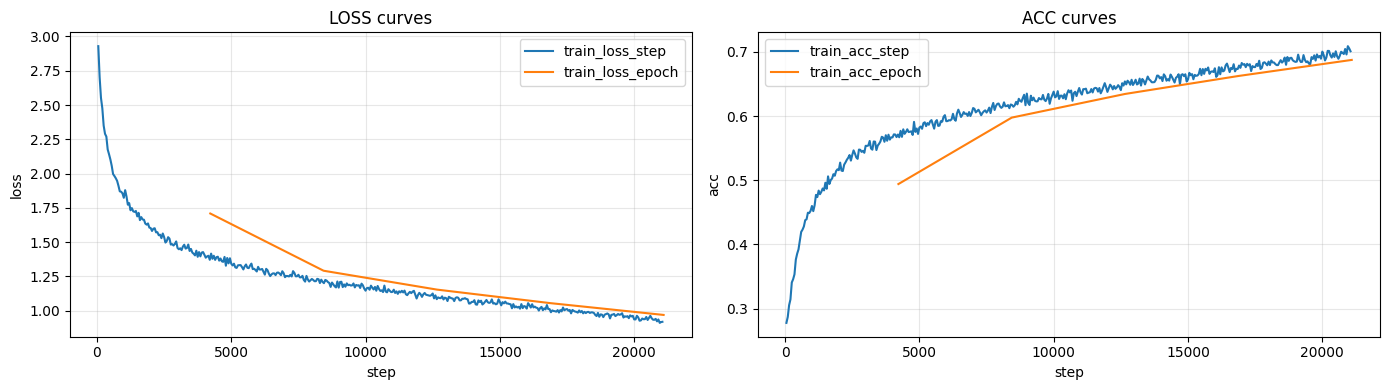

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric_hint in zip(axes, ['loss', 'acc']):
    metric_tags = [t for t in scalars_df['tag'].unique() if metric_hint in t.lower()] if not scalars_df.empty else []
    if metric_tags:
        for tag in metric_tags:
            curve = scalars_df[scalars_df['tag'] == tag]
            ax.plot(curve['step'], curve['value'], label=tag)
        ax.set_title(f'{metric_hint.upper()} curves')
        ax.set_xlabel('step')
        ax.set_ylabel(metric_hint)
        ax.grid(alpha=0.3)
        ax.legend()
    else:
        ax.set_title(f"No scalar tag containing {metric_hint!r}")
        ax.axis('off')

plt.tight_layout()
plt.show()

## Load Checkpoint For Inference

This section loads the trained checkpoint, reconstructs the GPT config, and prepares a tokenizer based on the training text file.

In [6]:
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
saved_hparams = ckpt.get('hyper_parameters', {})

cfg = GPT.get_default_config()
for k, v in saved_hparams.items():
    setattr(cfg, k, v)

gpt_model = GPT(cfg)

cleaned_sd = {}
for k, v in ckpt['state_dict'].items():
    if k.startswith('model._orig_mod.'):
        new_k = k.replace('model._orig_mod.', '')
    elif k.startswith('model.'):
        new_k = k.replace('model.', '')
    else:
        continue
    cleaned_sd[new_k] = v

missing, unexpected = gpt_model.load_state_dict(cleaned_sd, strict=False)
print('Missing keys:', len(missing))
print('Unexpected keys:', len(unexpected))

gpt_model.eval()

# Training on cluster stored an absolute Lustre path; fallback to local assignment2/assets.
saved_txt = Path(saved_hparams.get('txt_file', ''))
candidate_paths = []
if str(saved_txt):
    candidate_paths.append(saved_txt)
    if saved_txt.name:
        candidate_paths.append(ROOT / 'assets' / saved_txt.name)
candidate_paths.append(ROOT / 'assets' / 'book_EN_grimms_fairy_tales.txt')

resolved_txt = next((p for p in candidate_paths if p.exists()), None)
if resolved_txt is None:
    raise FileNotFoundError(
        'Could not locate training text file. Tried: ' + ', '.join(str(p) for p in candidate_paths)
    )

tokenizer = CharTokenizer(str(resolved_txt))
device = 'cuda' if torch.cuda.is_available() else 'cpu'
gpt_model = gpt_model.to(device)
print('Tokenizer source:', resolved_txt)
print('Inference device:', device)

True False
number of parameters: 10.73M
Missing keys: 0
Unexpected keys: 0
data has 540241 characters, 87 unique.
Tokenizer source: /home/minjih/Deep_Learning/assignment2/assets/book_EN_grimms_fairy_tales.txt
Inference device: cpu


In [9]:
@torch.inference_mode()
def sample_text(prompt: str, steps: int = 200, do_sample: bool = True, top_p: float = 0.9, top_k=None, temperature: float = 1.0):
    x = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device).unsqueeze(0)
    y = gpt_model.generate(x, max_new_tokens=steps, do_sample=do_sample, top_p=top_p, top_k=top_k, temperature=temperature)
    return tokenizer.decode(y[0].tolist())

prompts = [
    'Yesterday I went to the ',
    'Once upon a time, ',
    'The king said '
]

print('=== Greedy decoding ===')
for p in prompts:
    print('\nPrompt:', repr(p))
    print(sample_text(p, steps=160, do_sample=False, temperature=1.0))

print('\n\n=== Nucleus sampling (top_p=0.9) ===')
for p in prompts:
    print('\nPrompt:', repr(p))
    print(sample_text(p, steps=160, do_sample=True, top_p=0.8, temperature=0.8))

=== Greedy decoding ===

Prompt: 'Yesterday I went to the '
Yesterday I went to the king. Then the wild man said: ‘What a clever Elsie
we have!’ and sat down by her heart was a great deal of soldiers, and
said, ‘I will give you the fire and see

Prompt: 'Once upon a time, '
Once upon a time, and the soldier sprang out of the wood when the
fox came and said: ‘What do you do not such a thing?’ ‘I bring nothing
but it your hand,’ said the other, ‘I wil

Prompt: 'The king said '
The king said to him: ‘What a clever Elsie we have!’ and sat
down by her horse, and she saw that he was to be so much that he would
say the bed with him. Then he went away ag


=== Nucleus sampling (top_p=0.9) ===

Prompt: 'Yesterday I went to the '
Yesterday I went to the stable to the water and said: ‘Husband, the soldier
went into the water, and will be so long again, and I will soon find
you as fast as you can do it, and will 

Prompt: 'Once upon a time, '
Once upon a time, the bottom of the way off the window.

## Interpretation Notes

Use this checklist while reviewing the outputs:
- Training quality: `train_loss` should trend downward and `train_acc` upward.
- Generation quality: sampled outputs should be more diverse than greedy outputs but still remain syntactically plausible.
- Overfitting signals: if generated text becomes repetitive and memorized, try a larger corpus or stronger regularization.